YouTube Content Monetization Model


Part 1- Data Analysis and EDA


Import Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import joblib

Create Dataframe for youtube_ad_revenue_dataset.csv

In [4]:
url = 'D:/Shruti/Guvi/Content Monetization Modeler/Data/youtube_ad_revenue_dataset.csv'
df = pd.read_csv(url)

In [5]:
df.head() # Checking header

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [6]:
df.shape #Checking Number of rows and columns

(122400, 12)

In [7]:
df.tail() # Checking footer

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811
122399,vid_1056,2024-06-25 10:50:40.993199,9931,770.0,NaN,38466.837135,27.305703,517587,Tech,TV,CA,253.842824


In [116]:
df.dtypes # Checking DataTypes

video_id                    str
date                        str
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                    str
device                      str
country                     str
ad_revenue_usd          float64
dtype: object

Remove Duplicates

In [8]:
df.drop_duplicates(inplace=True) # Removing dulpicate records

In [9]:
df.shape # Checking the size

(120000, 12)

Handle Null Values

In [10]:
df.isna().sum() #Checking null values

video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [123]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,120000.000000,114000.000000,114000.000000,114000.000000,120000.000000,120000.000000,120000.000000
mean,9999.832333,1099.585044,274.349842,37540.749921,16.017910,502291.970050,252.711361
std,99.918405,519.526733,129.746796,12987.818758,8.084928,288364.967705,61.954125
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26364.159667,9.005928,252641.500000,199.892158
50%,10000.000000,1102.000000,274.000000,37522.221205,16.009269,503633.500000,252.678607
75%,10067.000000,1547.250000,387.000000,48782.739997,23.026064,752386.250000,305.613497
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [11]:
100* df.isnull().sum()/df.shape[0] #Checking null value percentage

video_id                0.0
date                    0.0
views                   0.0
likes                   5.0
comments                5.0
watch_time_minutes      5.0
video_length_minutes    0.0
subscribers             0.0
category                0.0
device                  0.0
country                 0.0
ad_revenue_usd          0.0
dtype: float64

Replacing null values in Numerical columns with median

In [12]:
df['likes']=df['likes'].fillna(df['likes'].median()) 
df['comments']=df['comments'].fillna(df['comments'].median()) 
df['watch_time_minutes']=df['watch_time_minutes'].fillna(df['watch_time_minutes'].median()) 

In [13]:
100* df.isnull().sum()/df.shape[0] #Checking null value percentage

video_id                0.0
date                    0.0
views                   0.0
likes                   0.0
comments                0.0
watch_time_minutes      0.0
video_length_minutes    0.0
subscribers             0.0
category                0.0
device                  0.0
country                 0.0
ad_revenue_usd          0.0
dtype: float64

Checking Categorial Columns for Unique Values

In [14]:
for col in df.columns:
  if df[col].nunique()<20 :
    print(df[col].value_counts())
    print("-"*50)

category
Education        20123
Music            20065
Tech             20028
Entertainment    20025
Gaming           19974
Lifestyle        19785
Name: count, dtype: int64
--------------------------------------------------
device
TV         30086
Mobile     29989
Desktop    29984
Tablet     29941
Name: count, dtype: int64
--------------------------------------------------
country
CA    20198
DE    20160
IN    20156
AU    19911
UK    19893
US    19682
Name: count, dtype: int64
--------------------------------------------------


Outlier Treatment

In [15]:
df.describe().round() 

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,120000.0,120000.0,120000.0,120000.0,120000.0,120000.0,120000.0
mean,10000.0,1100.0,274.0,37540.0,16.0,502292.0,253.0
std,100.0,506.0,126.0,12659.0,8.0,288365.0,62.0
min,9521.0,195.0,48.0,14659.0,2.0,1005.0,127.0
25%,9933.0,673.0,168.0,26950.0,9.0,252642.0,200.0
50%,10000.0,1102.0,274.0,37522.0,16.0,503634.0,253.0
75%,10067.0,1524.0,381.0,48210.0,23.0,752386.0,306.0
max,10468.0,2061.0,515.0,61558.0,30.0,999997.0,383.0


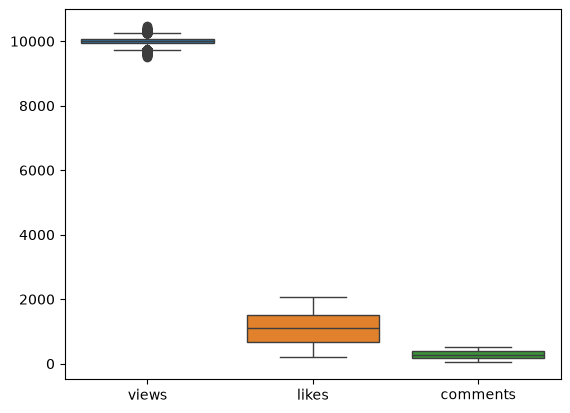

In [16]:
sns.boxplot(df[['views','likes','comments']])
plt.show()

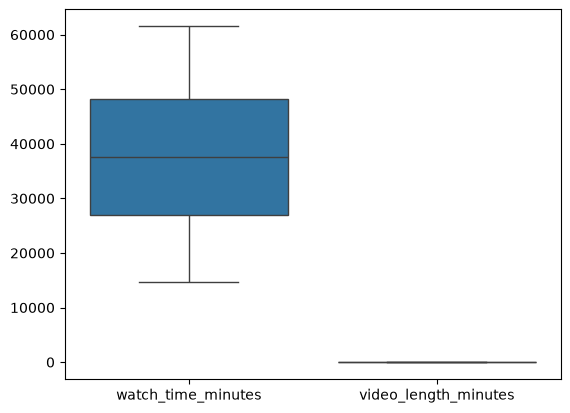

In [17]:
sns.boxplot(df[['watch_time_minutes','video_length_minutes']])
plt.show()

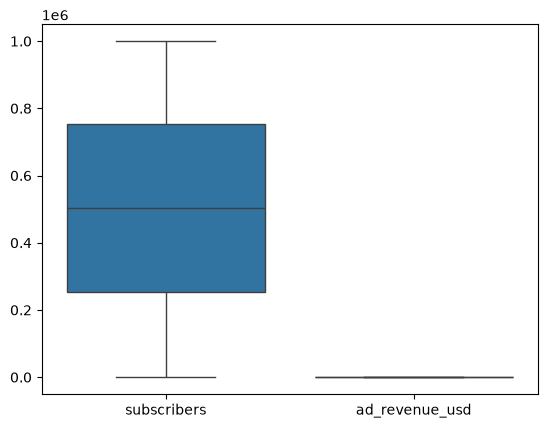

In [130]:
sns.boxplot(df[['subscribers','ad_revenue_usd']])
plt.show()

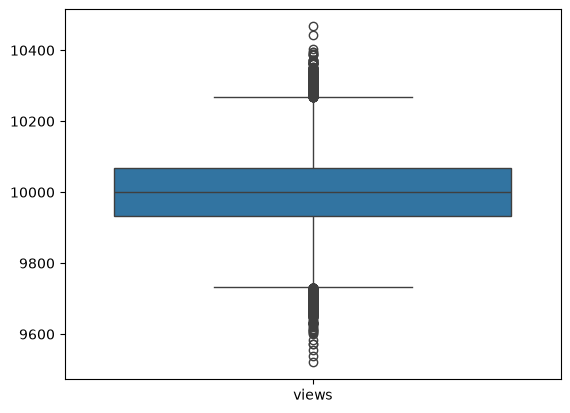

In [131]:
sns.boxplot(df[['views']])
plt.show()

Handling Outliers in 'view' column

In [18]:
#Capping the values

q1 = df['views'].quantile(0.25)
q3 = df['views'].quantile(0.75)

IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df['views'] = df['views'].clip(lower_bound,upper_bound)

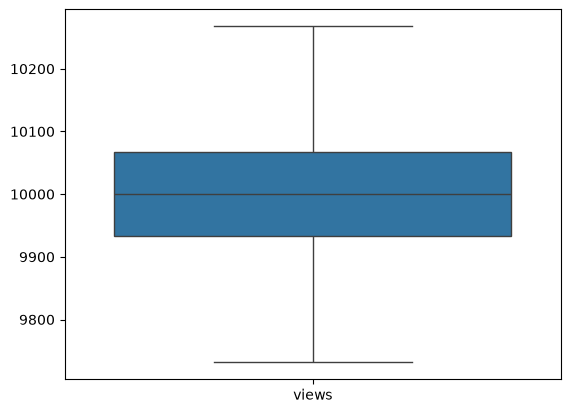

In [19]:
sns.boxplot(df[['views']])
plt.show()

Feature Understanding

Univariate Analysis

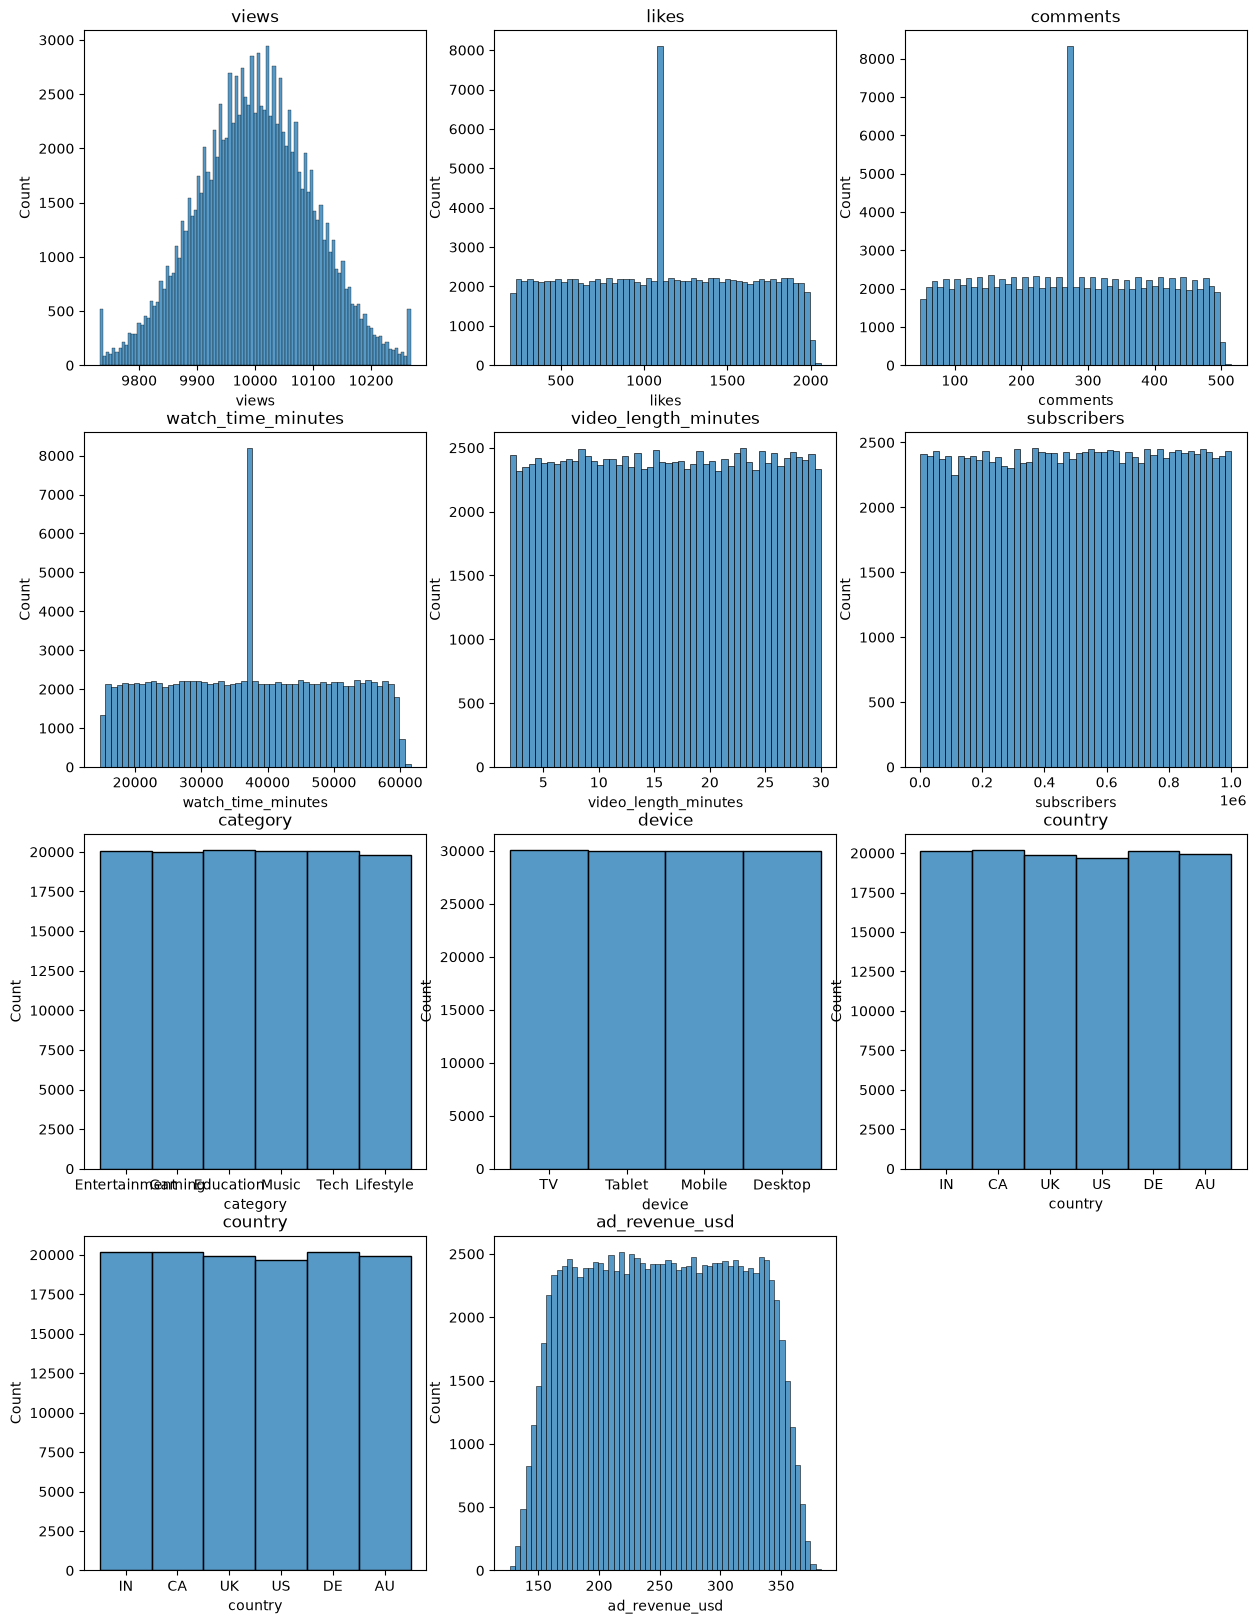

In [20]:
fig, axes = plt.subplots(4, 3, figsize=(15, 20))
cols_to_plot = ['views','likes','comments','watch_time_minutes','video_length_minutes','subscribers','category','device','country','country','ad_revenue_usd']

# Loop using enumerate to keep track of the index count
for i, col in enumerate(cols_to_plot):
    ax = axes.flat[i]
    #ax.plot(df[col])
    sns.histplot(data=df[col],ax=ax)
    ax.set_title(col)

# Turn off any remaining empty subplot windows
for j in range(len(cols_to_plot), len(axes.flat)):
    fig.delaxes(axes.flat[j]) # Deletes the unused layout frame entirely

plt.show()

BIVARIATE ANALYSIS

Pairplot

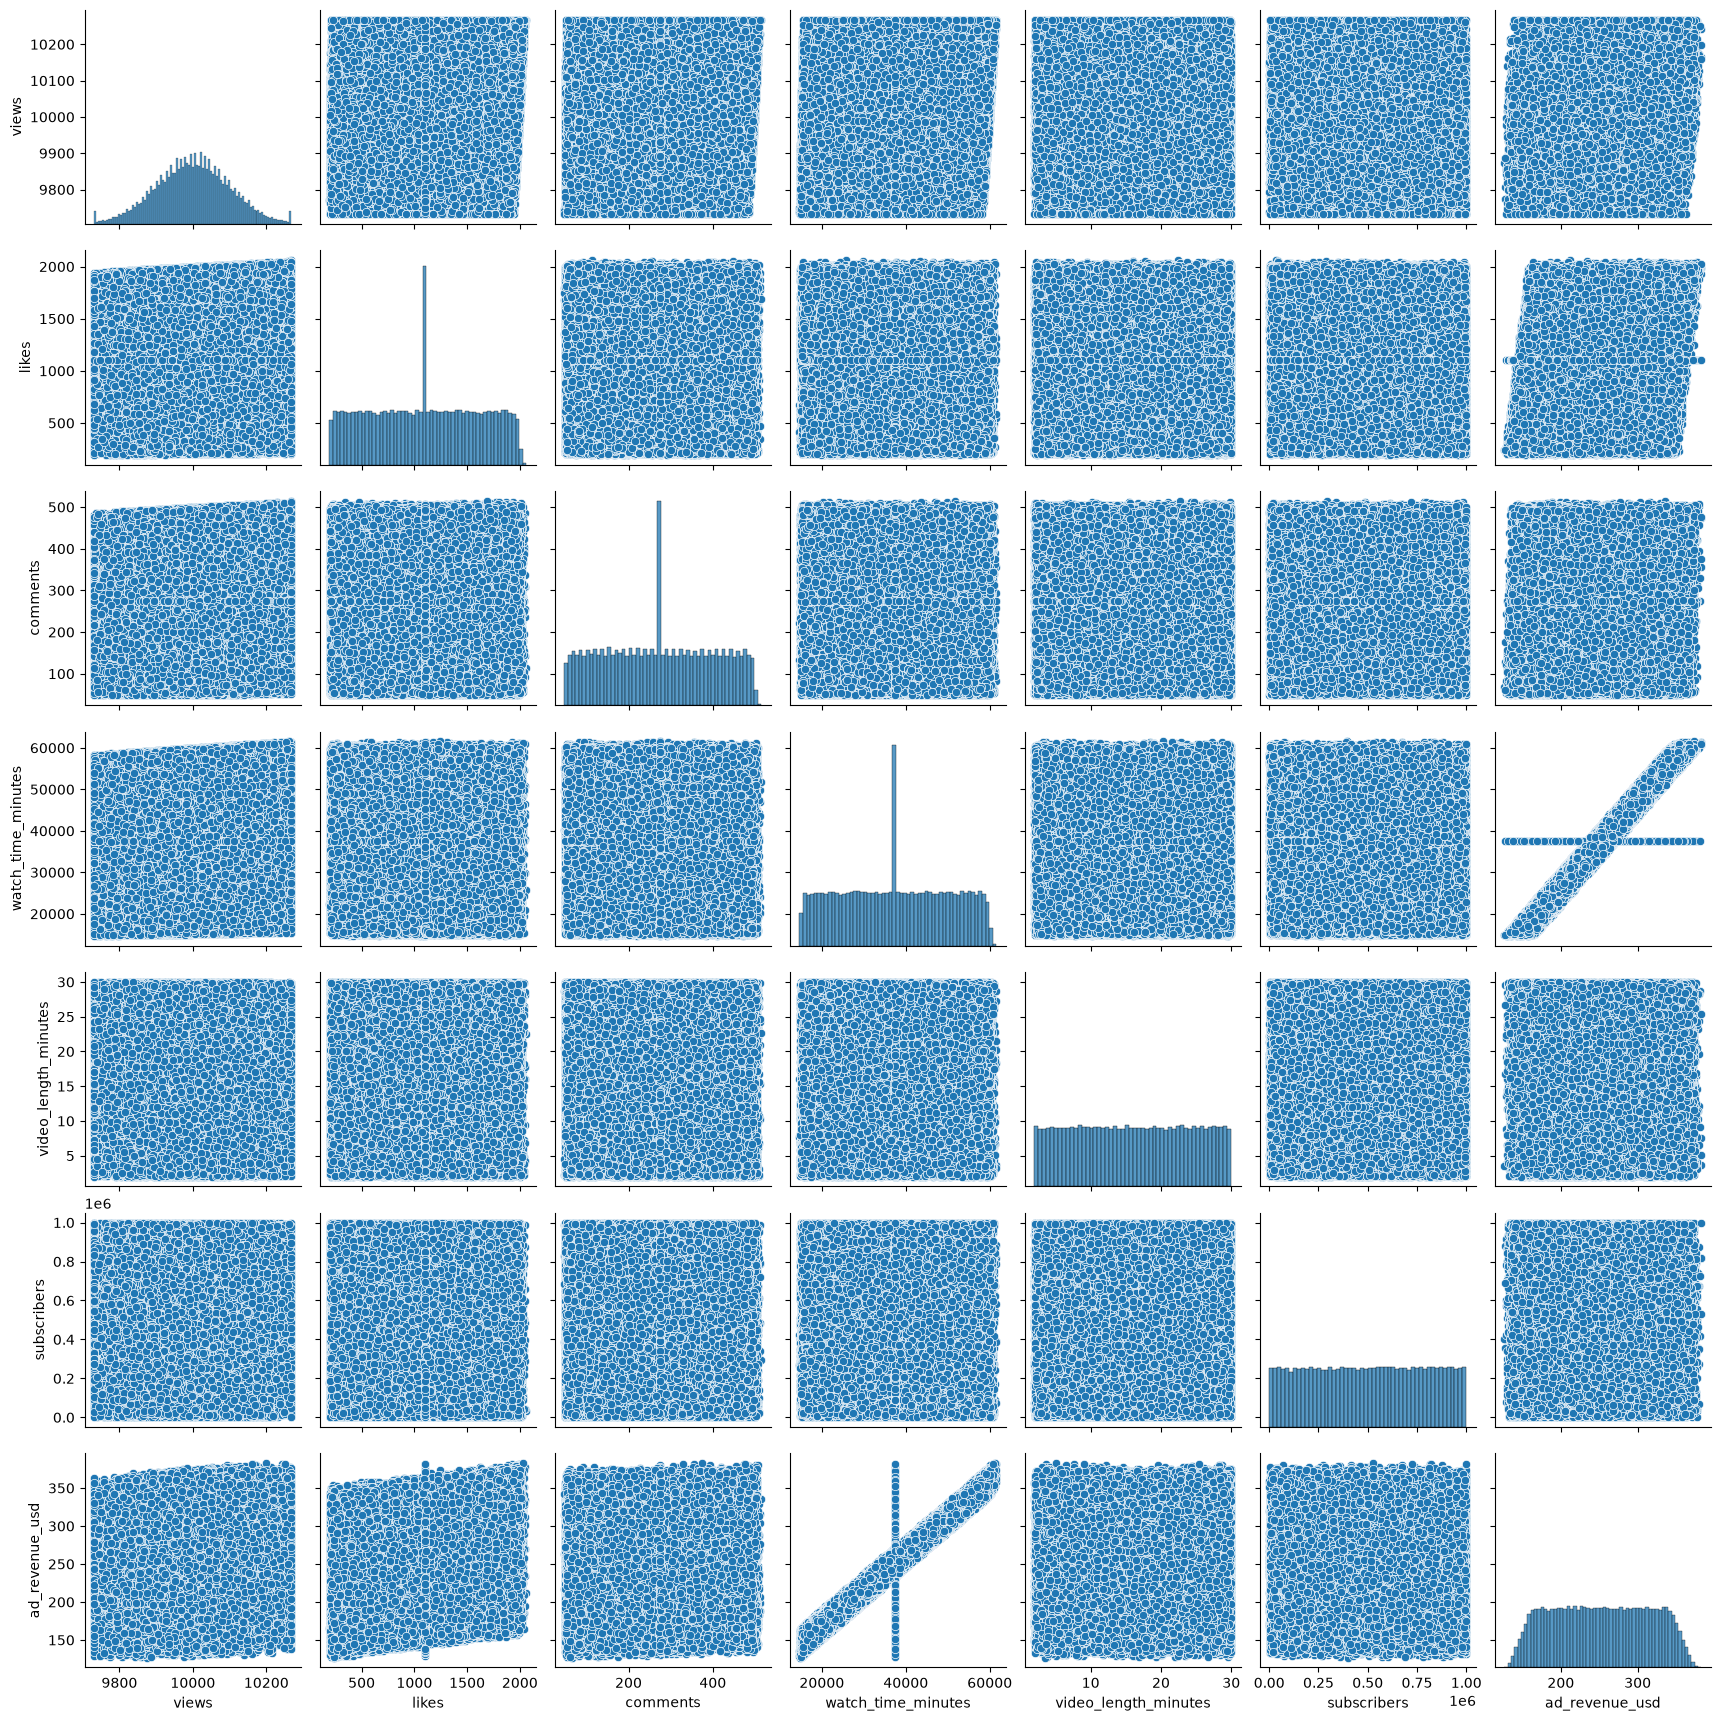

In [21]:
sns.pairplot(df)

Corelation Matrix

In [22]:
df[['views','likes','comments','video_length_minutes','subscribers','watch_time_minutes','ad_revenue_usd']].corr()

,views,likes,comments,video_length_minutes,subscribers,watch_time_minutes,ad_revenue_usd
views,1.000000,0.015133,0.018067,0.000838,0.000860,0.026027,0.037899
likes,0.015133,1.000000,-0.002032,0.001773,0.003524,0.002722,0.142571
comments,0.018067,-0.002032,1.000000,-0.002174,-0.001525,-0.000713,0.033630
video_length_minutes,0.000838,0.001773,-0.002174,1.000000,0.002015,-0.000388,0.000364
subscribers,0.000860,0.003524,-0.001525,0.002015,1.000000,0.004617,0.005065
watch_time_minutes,0.026027,0.002722,-0.000713,-0.000388,0.004617,1.000000,0.964052
ad_revenue_usd,0.037899,0.142571,0.033630,0.000364,0.005065,0.964052,1.000000


HeatMap

<Axes: >

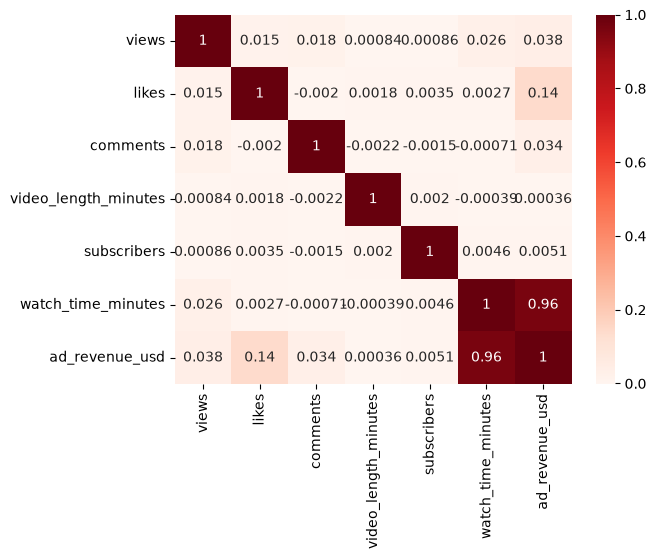

In [23]:
sns.heatmap(df[['views','likes','comments','video_length_minutes','subscribers','watch_time_minutes','ad_revenue_usd']].corr(),annot=True,cmap='Reds')

DATA ENCODING - Label Encoding

In [24]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [25]:
# Converting string values into numeric using lable encoder.

category_label = LabelEncoder()
df['category'] = category_label.fit_transform(df['category'])


In [26]:
# Converting string values into numeric using lable encoder.

device_label = LabelEncoder()
df['device'] = device_label.fit_transform(df['device'])

In [27]:
# Converting string values into numeric using lable encoder.

country_label = LabelEncoder()
df['country'] = device_label.fit_transform(df['country'])

In [28]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,1,2,3,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,2,3,1,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,0,2,1,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,1,1,4,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,0,1,1,165.514388


Handling Date Column

In [29]:
# Conveting datatype from string to DateTime

df['date'] = pd.to_datetime(df['date'] )
df.info()

<class 'pandas.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   video_id              120000 non-null  str           
 1   date                  120000 non-null  datetime64[us]
 2   views                 120000 non-null  int64         
 3   likes                 120000 non-null  float64       
 4   comments              120000 non-null  float64       
 5   watch_time_minutes    120000 non-null  float64       
 6   video_length_minutes  120000 non-null  float64       
 7   subscribers           120000 non-null  int64         
 8   category              120000 non-null  int64         
 9   device                120000 non-null  int64         
 10  country               120000 non-null  int64         
 11  ad_revenue_usd        120000 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(5), str(1)
memory usage: 11.9 MB


In [30]:
# Creating new featues from Date Column

df['Date_Day'] = df['date'].dt.day
df['Date_Month'] = df['date'].dt.month
df['Date_Year'] = df['date'].dt.year

df['Time_Hour']=df['date'].dt.hour
df['Time_Minutes']=df['date'].dt.minute
df['Time_Seconds']=df['date'].dt.second



In [31]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,Date_Day,Date_Month,Date_Year,Time_Hour,Time_Minutes,Time_Seconds
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,1,2,3,203.178237,24,9,2024,10,50,40
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,2,3,1,140.880508,22,9,2024,10,50,40
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,0,2,1,360.134008,21,11,2024,10,50,40
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,1,1,4,224.638261,28,1,2025,10,50,40
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,0,1,1,165.514388,28,4,2025,10,50,40


In [32]:
# Drop Date column

df.drop(columns=["date"], inplace=True)

In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              120000 non-null  str    
 1   views                 120000 non-null  int64  
 2   likes                 120000 non-null  float64
 3   comments              120000 non-null  float64
 4   watch_time_minutes    120000 non-null  float64
 5   video_length_minutes  120000 non-null  float64
 6   subscribers           120000 non-null  int64  
 7   category              120000 non-null  int64  
 8   device                120000 non-null  int64  
 9   country               120000 non-null  int64  
 10  ad_revenue_usd        120000 non-null  float64
 11  Date_Day              120000 non-null  int32  
 12  Date_Month            120000 non-null  int32  
 13  Date_Year             120000 non-null  int32  
 14  Time_Hour             120000 non-null  int32  
 15  Time_Minutes    

Handle Video_id Columne

In [34]:
# Converting video_id column to table index
df = df.set_index("video_id")
df.head()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,Date_Day,Date_Month,Date_Year,Time_Hour,Time_Minutes,Time_Seconds
video_id,,,,,,,,,,,,,,,,
vid_3092,9936,1221.0,320.0,26497.214184,2.862137,228086,1,2,3,203.178237,24,9,2024,10,50,40
vid_3459,10017,642.0,346.0,15209.747445,23.738069,736015,2,3,1,140.880508,22,9,2024,10,50,40
vid_4784,10097,1979.0,187.0,57332.658498,26.200634,240534,0,2,1,360.134008,21,11,2024,10,50,40
vid_4078,10034,1191.0,242.0,31334.517771,11.770340,434482,1,1,4,224.638261,28,1,2025,10,50,40
vid_3522,9889,1858.0,477.0,15665.666434,6.635854,42030,0,1,1,165.514388,28,4,2025,10,50,40


Feature Engineering

Adding New Features - 
"engagement_rate"
"avg_view_duration_min"
"like_to_comment_ratio"
"view_to_sub_ratio"

In [35]:
# 1. Engagement Rate: (likes + comments) / views
df["engagement_rate"] = (df["likes"] + df["comments"]).div(df["views"]).fillna(0)

# 2. Average View Duration: watch_time_minutes / views
df["avg_view_duration_min"] = df["watch_time_minutes"].div(df["views"]).fillna(0)

# 3. Like to Comment Ratio: likes / comments
df["like_to_comment_ratio"] = df["likes"].div(df["comments"]).fillna(0)

# 4. Reach Index: views / subscribers
df["view_to_sub_ratio"] = df["views"].div(df["subscribers"]).fillna(0)

# Inspect the engineered feature matrix
print(
    df[
        [
            "engagement_rate",
            "avg_view_duration_min",
            "like_to_comment_ratio",
            "view_to_sub_ratio",
        ]
    ]
)

          engagement_rate  avg_view_duration_min  like_to_comment_ratio  \
video_id                                                                  
vid_3092         0.155093               2.666789               3.815625   
vid_3459         0.098632               1.518393               1.855491   
vid_4784         0.214519               5.678187              10.582888   
vid_4078         0.142814               3.122834               4.921488   
vid_3522         0.236121               1.584151               3.895178   
...                   ...                    ...                    ...   
vid_2902         0.184715               4.270345              11.380952   
vid_3890         0.174961               5.683620              27.126984   
vid_3934         0.094867               2.683327               2.554745   
vid_4260         0.168164               5.563221              15.245283   
vid_1056         0.105125               3.873410               2.810219   

          view_to_sub_ra

Feature Scaling - Uniform Scale

In [36]:
scaler = StandardScaler()
X = df.drop('ad_revenue_usd',axis=1)
y= df['ad_revenue_usd']
X = pd.DataFrame(scaler.fit_transform(X),columns=X.columns)
X.head()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,Date_Day,Date_Month,Date_Year,Time_Hour,Time_Minutes,Time_Seconds,engagement_rate,avg_view_duration_min,like_to_comment_ratio,view_to_sub_ratio
0,-0.643342,0.239537,0.361120,-0.872319,-1.627204,-0.950903,-0.875626,0.447557,0.298776,0.945248,0.719067,-0.877982,0.0,0.0,0.0,0.339012,-0.859247,-0.341523,-0.082737
1,0.172974,-0.903896,0.566717,-1.763982,0.954887,0.810515,-0.290992,1.342431,-0.876119,0.717614,0.719067,-0.877982,0.0,0.0,0.0,-0.743432,-1.766777,-0.726120,-0.181419
2,0.979213,1.736466,-0.690587,1.563550,1.259475,-0.907735,-1.460260,0.447557,-0.876119,0.603796,1.299074,-0.877982,0.0,0.0,0.0,1.478325,1.520538,0.986279,-0.087959
3,0.344300,0.180291,-0.255671,-0.490193,-0.525371,-0.235154,-0.875626,-0.447318,0.886223,1.400518,-1.600963,1.138976,0.0,0.0,0.0,0.103617,-0.498853,-0.124542,-0.150172
4,-1.117008,1.497510,1.602610,-1.727966,-1.160443,-1.596116,-1.460260,-0.447318,-0.876119,1.400518,-0.730952,1.138976,0.0,0.0,0.0,1.892470,-1.714812,-0.325914,0.548912


Export the fitted scaler object

In [37]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Test Train Split

In [38]:

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.7,test_size=0.3,random_state=101)

Model Creation & Evaluation

In [39]:
# Initialize the 5 regression models
models = {
    "LinearRegression" : LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree Regressor":DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),

}

# Train and evaluate each model automatically

for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)


    # Predict for X_train
    predictions = model.predict(X_train)

    # Evaluate
    r2 = r2_score(y_train, predictions)
    mae = mean_absolute_error(y_train, predictions)
    rmse = root_mean_squared_error(y_train, predictions)
    print(f"=== {name} for Train Dataset===")
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : ${mae:.2f}\n")
    print(f"RMSE      : ${rmse:.2f}\n")

    # Predict
    predictions = model.predict(X_test)

    # Evaluate
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    print(f"=== {name} for Test Dataset====")
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : ${mae:.2f}\n")
    print(f"RMSE      : ${rmse:.2f}\n")




=== LinearRegression for Train Dataset===
R² Score : 0.9504
MAE      : $3.21

RMSE      : $13.79

=== LinearRegression for Test Dataset====
R² Score : 0.9501
MAE      : $3.23

RMSE      : $13.86

=== Ridge Regression for Train Dataset===
R² Score : 0.9504
MAE      : $3.22

RMSE      : $13.79

=== Ridge Regression for Test Dataset====
R² Score : 0.9501
MAE      : $3.23

RMSE      : $13.86

=== Lasso Regression for Train Dataset===
R² Score : 0.9504
MAE      : $3.26

RMSE      : $13.80

=== Lasso Regression for Test Dataset====
R² Score : 0.9501
MAE      : $3.27

RMSE      : $13.86

=== Decision Tree Regressor for Train Dataset===
R² Score : 0.9496
MAE      : $4.89

RMSE      : $13.90

=== Decision Tree Regressor for Test Dataset====
R² Score : 0.9475
MAE      : $5.05

RMSE      : $14.21

=== Random Forest for Train Dataset===
R² Score : 0.9927
MAE      : $1.39

RMSE      : $5.28

=== Random Forest for Test Dataset====
R² Score : 0.9474
MAE      : $3.73

RMSE      : $14.23



**1. The Winner: Linear / Ridge RegressionThe Metrics:**

 Both achieve an R² of 0.9501, an MAE of $3.23, and an RMSE of $13.86 on the test dataset.
 
 **Why they win:** Look at the gap between their Train and Test metrics. The scores are nearly identical (e.g., Train MAE $3.21 vs Test MAE $3.23). This proves the linear models have perfectly generalized the underlying patterns without memorizing noise. They sit right in the machine learning "sweet spot."
 
 **2. The Overfitting Trap:** Random ForestAt first glance, Random Forest looks like the winner because it achieves an incredible Train MAE of only $1.39 and a Train RMSE of $5.28.
 
 **The Problem:** When you look at its Test Dataset performance, the MAE jumps to $3.73 and the RMSE spikes to $14.23.
 **Why it loses:** This massive performance gap is the textbook definition of overfitting. The Random Forest memorized individual data rows and noise in your training set. When it was shown the unseen test dataset, it struggled, resulting in worse error rates than the simpler linear models.
 
 **3. Underperforming:** Decision Tree The Metrics: Test MAE of $5.05 and RMSE of $14.21.
 
 **Why it loses:** Single decision trees are usually too simple to capture complex data smoothly. It is underperforming across all metrics compared to the other four models.
 


Exporting Label Encoder

In [105]:
# Dictionary to hold encoders
encoders = {}
categorical_cols = ["category", "device", "country"]

# Label Encode each column sequentially
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le  # Save fitted encoder object

# Save the dictionary of encoders to a file
joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']

Hyper Parameter Tuning and Exporting Ridge model

In [42]:
# 1. Define a broad logarithmic search space for alpha
# This tests: 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0
param_grid = {"alpha": np.logspace(-3, 3, 7)}

# 2. Setup Cross-Validation Search
# cv=5 splits your data into 5 chunks to ensure the alpha works across different slices
ridge_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error", # Optimizing to find the absolute lowest MAE
    n_jobs=-1
)

# 3. Fit the grid search on your scaled training metrics
ridge_search.fit(X_train, y_train)

# 4. Extract the best model configuration
best_ridge_model = ridge_search.best_estimator_
best_alpha = ridge_search.best_params_["alpha"]

# 5. Evaluate the optimized tuned model on your test dataset
y_pred_tuned = best_ridge_model.predict(X_test)

print("=== 🏆 Ridge Tuning Report ===")
print(f"Optimal Alpha Penalty Value: {best_alpha}")
print(f"Tuned Test R² Score        : {r2_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Test MAE             : ${mean_absolute_error(y_test, y_pred_tuned):.2f}")
print(f"Tuned Test RMSE            : ${np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.2f}")

# ==========================================
# 6. EXPORT THE TUNED MODEL
# ==========================================

TARGET_DIR = r"D:\Shruti\Guvi\Content Monetization Modeler\venv\Scripts"
joblib.dump(best_ridge_model, f"{TARGET_DIR}\\ridge_model.pkl")
print("\n✅ Tuned ridge_model.pkl exported successfully!")



=== 🏆 Ridge Tuning Report ===
Optimal Alpha Penalty Value: 0.01
Tuned Test R² Score        : 0.9501
Tuned Test MAE             : $3.23
Tuned Test RMSE            : $13.86

✅ Tuned ridge_model.pkl exported successfully!
